# Country-by-country quarterly OLS/IV coefficients against euro-sample $\xi$

This notebook runs separate time-series regressions for each country using quarterly data.

Configurable elements:

- `estimation_mode`: `"ols"` or `"iv"`
- `plot_horizons`: the CPI horizons to estimate and plot
- `y_lags = 3`
- `shock_lags = 3`
- optional lagged macro controls only, with 3 lags and no contemporaneous controls

For `h = 0`, the regression uses quarterly CPI on quarterly oil.
For `h > 0`, the regression uses cumulative CPI on cumulative oil, summing from `t` through `t+h` in the same spirit as the panel cumulative notebooks.
Lag terms remain lags of the underlying quarterly CPI and quarterly oil series.

For each country, the plot x-axis uses either the plain average exposure measure over the regression sample or the shock-weighted version, depending on the configuration toggle.

$$\bar{\xi}_m = \frac{1}{T_m}\sum_t \xi_{m,t} \qquad \text{or} \qquad \tilde{\xi}_m = \frac{\sum_t \xi_{m,t} u_t^2}{\sum_t u_t^2}$$

where $u_t = \text{oil\_pct\_change}_t$, computed over that country's regression sample.

This euro notebook restricts the sample to euro-area countries and keeps observations only from each country's euro-adoption quarter onward.

In IV mode, the contemporaneous and cumulative oil shocks are instrumented with the matching quarterly Kaenzig news shock series.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp
from io_networks.policy_rates import EURO_ADOPTION_STARTS


In [2]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
news_path = ROOT / "data/processed/oil/kaenzig_oil_supply_surprises_quarterly.csv"
news_column = "news_shock"

panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    },
]

macro_controls = ["output_gap", "policy_rate", "exchange_rate"]
estimation_mode = "ols"  # "ols" or "iv"
exclude_countries = []
plot_horizons = [0,4]
irf_horizons = list(range(12))
y_lags = 3
shock_lags = 3
control_lags = 3
lag_xi_by_one_year_for_xi_x_oil = True
x_axis_metric = "xi"
xi_aggregation = "average"  # "average" or "shock_weighted"
y_axis_mode = "coef"  # "coef" or "coef_over_metric"
cross_section_summary_mode = "wls"  # "wls" or "correlation"
ci_alpha = 0.05

XI_AXIS_OPTIONS = {
    "xi": {
        "panel_col": "xi",
        "result_col_base": "xi",
        "label": "xi in the country regression sample",
    },
    "xi_amp1": {
        "panel_col": "xi_amp_1",
        "result_col_base": "xi_amp1",
        "label": "xi_amp1 in the country regression sample",
    },
    "xi_amp2": {
        "panel_col": "xi_amp_2",
        "result_col_base": "xi_amp2",
        "label": "xi_amp2 in the country regression sample",
    },
}

Y_AXIS_OPTIONS = {
    "coef": {
        "label": "Country-specific {mode_label} coefficient on shock",
    },
    "coef_over_metric": {
        "label": "Country-specific {mode_label} coefficient divided by the sample metric",
    },
}

if estimation_mode not in {"ols", "iv"}:
    raise ValueError("estimation_mode must be 'ols' or 'iv'")

if x_axis_metric not in XI_AXIS_OPTIONS:
    raise ValueError(f"x_axis_metric must be one of {sorted(XI_AXIS_OPTIONS)}")

if xi_aggregation not in {"average", "shock_weighted"}:
    raise ValueError("xi_aggregation must be 'average' or 'shock_weighted'")

if y_axis_mode not in Y_AXIS_OPTIONS:
    raise ValueError(f"y_axis_mode must be one of {sorted(Y_AXIS_OPTIONS)}")

if cross_section_summary_mode not in {"wls", "correlation"}:
    raise ValueError("cross_section_summary_mode must be 'wls' or 'correlation'")

panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    news_path=news_path,
    news_column=news_column,
    cpi_freq="Q",
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
)

euro_start = (
    pd.Series(EURO_ADOPTION_STARTS, name="euro_start")
    .rename_axis("country")
    .reset_index()
)
euro_start["euro_start"] = pd.PeriodIndex(euro_start["euro_start"], freq="Q")

panel_df = panel_df.copy()
panel_df["period_q"] = pd.PeriodIndex(panel_df["period"].astype(str), freq="Q")

panel_df = (
    panel_df.merge(euro_start, on="country", how="inner")
    .loc[lambda d: d["period_q"] >= d["euro_start"]]
    .drop(columns=["period_q", "euro_start"])
    .sort_values(["country", "time_index"])
    .reset_index(drop=True)
)

print(f"Panel rows: {len(panel_df):,}")
print(f"Countries: {panel_df['country'].nunique()}")
print(f"Excluded countries: {exclude_countries}")
print(f"Periods: {panel_df['period'].nunique()}")
print(f"estimation_mode: {estimation_mode}")
print(f"Plot horizons: {plot_horizons}")
print(f"IRF horizons: {irf_horizons}")
print(f"x_axis_metric: {x_axis_metric}")
print(f"xi_aggregation: {xi_aggregation}")
print(f"y_axis_mode: {y_axis_mode}")
print(f"cross_section_summary_mode: {cross_section_summary_mode}")
panel_df.head()


Panel rows: 1,476
Countries: 19
Excluded countries: []
Periods: 96
estimation_mode: ols
Plot horizons: [0, 4]
IRF horizons: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
x_axis_metric: xi
xi_aggregation: average
y_axis_mode: coef
cross_section_summary_mode: wls


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,xi_amp_1,xi_amp_2,xi_amp,news,xi_x_news,exchange_rate,output_gap,policy_rate
0,AUT,1999,1999-Q1,7996,0.019423,-0.004137,-0.000078,0.001369,0.007268,0.009326,0.016593,0.881893,0.016708,-2.573822,-0.001662,3.000000
1,AUT,1999,1999-Q2,7997,0.019423,0.315823,0.005983,0.001276,0.007268,0.009326,0.016593,-0.036499,-0.000691,0.059417,0.000792,2.500000
2,AUT,1999,1999-Q3,7998,0.019423,0.245995,0.004661,-0.000091,0.007268,0.009326,0.016593,1.836964,0.034802,0.007928,0.009650,2.500000
3,AUT,1999,1999-Q4,7999,0.019423,0.140305,0.002658,0.007191,0.007268,0.009326,0.016593,-0.792292,-0.015010,0.010133,0.012006,2.833333
4,AUT,2000,2000-Q1,8000,0.032090,0.117547,0.002283,0.007320,0.010810,0.012849,0.023659,1.206933,0.023442,0.050932,0.005781,3.250000


In [3]:
def build_country_regression_sample(
    country_df: pd.DataFrame,
    *,
    horizon: int,
    macro_controls: list[str],
    include_lagged_controls: bool,
    estimation_mode: str,
) -> tuple[pd.DataFrame, str, str, str | None, list[str], list[str]]:
    if horizon < 0:
        raise ValueError("horizon must be >= 0")

    work = country_df[[
        "country",
        "period",
        "time_index",
        "year",
        "xi",
        "xi_amp_1",
        "xi_amp_2",
        "cpi_pct_change",
        "oil_pct_change",
        "news",
        *macro_controls,
    ]].copy()
    work = work.sort_values("time_index").reset_index(drop=True)

    if horizon == 0:
        dep_col = "cpi_pct_change_h0"
        shock_col = "oil_pct_change_h0"
        instrument_col = "news_h0" if estimation_mode == "iv" else None
        work[dep_col] = work["cpi_pct_change"]
        work[shock_col] = work["oil_pct_change"]
        if instrument_col is not None:
            work[instrument_col] = work["news"]
    else:
        dep_col = f"cum_cpi_lead{horizon}"
        shock_col = f"cum_oil_lead{horizon}"
        instrument_col = f"cum_news_lead{horizon}" if estimation_mode == "iv" else None
        work[dep_col] = 0.0
        work[shock_col] = 0.0
        if instrument_col is not None:
            work[instrument_col] = 0.0
        for step in range(horizon + 1):
            shifted_cpi = work["cpi_pct_change"].shift(-step)
            shifted_oil = work["oil_pct_change"].shift(-step)
            shifted_news = work["news"].shift(-step)
            work[dep_col] = shifted_cpi if step == 0 else work[dep_col] + shifted_cpi
            work[shock_col] = shifted_oil if step == 0 else work[shock_col] + shifted_oil
            if instrument_col is not None:
                work[instrument_col] = shifted_news if step == 0 else work[instrument_col] + shifted_news

    y_lag_cols = []
    for lag in range(1, y_lags + 1):
        col = f"cpi_pct_change_lag{lag}"
        work[col] = work["cpi_pct_change"].shift(lag)
        y_lag_cols.append(col)

    shock_lag_cols = []
    instrument_lag_cols = []
    for lag in range(1, shock_lags + 1):
        shock_lag_col = f"oil_pct_change_lag{lag}"
        work[shock_lag_col] = work["oil_pct_change"].shift(lag)
        shock_lag_cols.append(shock_lag_col)
        if estimation_mode == "iv":
            instrument_lag_col = f"news_lag{lag}"
            work[instrument_lag_col] = work["news"].shift(lag)
            instrument_lag_cols.append(instrument_lag_col)

    control_cols = []
    if include_lagged_controls:
        for control in macro_controls:
            for lag in range(1, control_lags + 1):
                col = f"{control}_lag{lag}"
                work[col] = work[control].shift(lag)
                control_cols.append(col)

    x_cols = [shock_col, *shock_lag_cols, *y_lag_cols]
    z_cols = [instrument_col, *instrument_lag_cols, *y_lag_cols] if estimation_mode == "iv" else []
    if include_lagged_controls:
        x_cols.extend(control_cols)
        if estimation_mode == "iv":
            z_cols.extend(control_cols)

    required_cols = [dep_col, *x_cols]
    if estimation_mode == "iv":
        required_cols.extend(z_cols)

    work = work.dropna(subset=required_cols).copy()
    return work, dep_col, shock_col, instrument_col, x_cols, z_cols


def compute_sample_metric(work: pd.DataFrame, metric_col: str, aggregation: str) -> float:
    values = work[metric_col].astype(float)
    if aggregation == "average":
        return float(values.mean())
    if aggregation == "shock_weighted":
        weights = work["oil_pct_change"].astype(float) ** 2
        denom = float(weights.sum())
        if denom == 0.0:
            return float("nan")
        return float((values * weights).sum() / denom)
    raise ValueError(f"Unsupported aggregation: {aggregation}")


def has_full_column_rank(matrix: pd.DataFrame) -> bool:
    values = np.asarray(matrix, dtype=float)
    if values.ndim != 2 or values.size == 0:
        return False
    return int(np.linalg.matrix_rank(values)) == int(values.shape[1])


def build_iv_rank_check_matrix(x: pd.DataFrame, z: pd.DataFrame) -> pd.DataFrame:
    # x and z intentionally share exogenous regressors; drop duplicate columns before testing rank.
    combined = pd.concat([x, z], axis=1)
    return combined.loc[:, ~combined.columns.duplicated()].copy()


def run_country_regression(
    df: pd.DataFrame,
    *,
    horizon: int,
    include_lagged_controls: bool,
    estimation_mode: str,
) -> pd.DataFrame:
    rows = []

    for country, country_df in df.groupby("country"):
        work, dep_col, shock_col, instrument_col, x_cols, z_cols = build_country_regression_sample(
            country_df,
            horizon=horizon,
            macro_controls=macro_controls,
            include_lagged_controls=include_lagged_controls,
            estimation_mode=estimation_mode,
        )
        min_required_obs = len(z_cols) if estimation_mode == "iv" else len(x_cols)
        if work.empty or len(work) <= min_required_obs:
            continue

        y = pd.to_numeric(work[dep_col], errors="coerce")
        x = sm.add_constant(work[x_cols], has_constant="add")
        if not has_full_column_rank(x):
            continue
        if estimation_mode == "iv":
            z = sm.add_constant(work[z_cols], has_constant="add")
            if not has_full_column_rank(z):
                continue
            if not has_full_column_rank(build_iv_rank_check_matrix(x, z)):
                continue
            try:
                model = IV2SLS(y, x, z).fit()
            except np.linalg.LinAlgError:
                continue
            first_stage = sm.OLS(work[shock_col], z, missing="raise").fit()
            first_stage_coef = float(first_stage.params[instrument_col])
            first_stage_t = float(first_stage.tvalues[instrument_col])
            first_stage_p = float(first_stage.pvalues[instrument_col])
        else:
            try:
                model = sm.OLS(y, x, missing="raise").fit()
            except np.linalg.LinAlgError:
                continue
            first_stage_coef = float("nan")
            first_stage_t = float("nan")
            first_stage_p = float("nan")

        shock_se = float(model.bse[shock_col])
        shock_ci = model.conf_int(alpha=ci_alpha).loc[shock_col]
        weight_inv_var = float(1.0 / (shock_se ** 2)) if shock_se > 0 else float("nan")

        row = {
            "country": country,
            "horizon": horizon,
            "nobs": int(model.nobs),
            "estimation_mode": estimation_mode,
            "shock_col": shock_col,
            "instrument_col": instrument_col,
            "coef_shock": float(model.params[shock_col]),
            "se_shock": shock_se,
            "shock_ci_low": float(shock_ci.iloc[0]),
            "shock_ci_high": float(shock_ci.iloc[1]),
            "t_shock": float(model.tvalues[shock_col]),
            "p_shock": float(model.pvalues[shock_col]),
            "r2": float(getattr(model, "rsquared", float("nan"))),
            "include_lagged_controls": include_lagged_controls,
            "n_regressors_ex_const": len(x_cols),
            "weight_inv_var": weight_inv_var,
            "first_stage_coef": first_stage_coef,
            "first_stage_t": first_stage_t,
            "first_stage_p": first_stage_p,
        }
        for metric_name, metric_spec in XI_AXIS_OPTIONS.items():
            average_col = f"{metric_spec['result_col_base']}_average"
            shock_weighted_col = f"{metric_spec['result_col_base']}_shock_weighted"
            legacy_weighted_col = f"{metric_spec['result_col_base']}_weighted"
            row[average_col] = compute_sample_metric(work, metric_spec["panel_col"], "average")
            row[shock_weighted_col] = compute_sample_metric(work, metric_spec["panel_col"], "shock_weighted")
            row[legacy_weighted_col] = row[f"{metric_spec['result_col_base']}_{xi_aggregation}"]
        rows.append(row)

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["horizon", "country"]).reset_index(drop=True)


def run_spec_for_horizons(
    df: pd.DataFrame,
    *,
    horizons: list[int],
    include_lagged_controls: bool,
    estimation_mode: str,
) -> pd.DataFrame:
    parts = []
    for horizon in horizons:
        result = run_country_regression(
            df,
            horizon=horizon,
            include_lagged_controls=include_lagged_controls,
            estimation_mode=estimation_mode,
        )
        parts.append(result)
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, axis=0, ignore_index=True)


def plot_coef_vs_weighted_xi(
    results: pd.DataFrame,
    *,
    title_prefix: str,
    x_axis_metric: str = x_axis_metric,
    y_axis_mode: str = y_axis_mode,
) -> None:
    metric_spec = XI_AXIS_OPTIONS[x_axis_metric]
    metric_col = f"{metric_spec['result_col_base']}_{xi_aggregation}"
    y_axis_spec = Y_AXIS_OPTIONS[y_axis_mode]

    for horizon in sorted(results["horizon"].unique()):
        horizon_df = results.loc[results["horizon"] == horizon].copy()
        horizon_df = horizon_df.dropna(
            subset=[metric_col, "coef_shock", "se_shock", "weight_inv_var", "shock_ci_low", "shock_ci_high"]
        ).copy()
        if y_axis_mode == "coef_over_metric":
            horizon_df = horizon_df.loc[horizon_df[metric_col] != 0].copy()
        if horizon_df.empty:
            continue

        if y_axis_mode == "coef_over_metric":
            horizon_df["y_value"] = horizon_df["coef_shock"] / horizon_df[metric_col]
            y_line_ref = 1.0
        else:
            horizon_df["y_value"] = horizon_df["coef_shock"]
            y_line_ref = 0.0

        fig, ax = plt.subplots(figsize=(10, 7))
        marker_sizes = 40.0 * horizon_df["weight_inv_var"] / horizon_df["weight_inv_var"].median()
        ax.scatter(
            horizon_df[metric_col],
            horizon_df["y_value"],
            s=marker_sizes,
            c="#4d4d4d",
            alpha=0.85,
            edgecolors="white",
            linewidths=0.6,
        )

        for row in horizon_df.itertuples(index=False):
            ax.annotate(
                row.country,
                (getattr(row, metric_col), row.y_value),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                color="#4d4d4d",
            )

        if cross_section_summary_mode == "wls":
            fit = sm.WLS(
                horizon_df["y_value"],
                sm.add_constant(horizon_df[metric_col], has_constant="add"),
                weights=horizon_df["weight_inv_var"],
            ).fit()
            x_line = pd.Series(sorted(horizon_df[metric_col]))
            x_line_design = sm.add_constant(x_line, has_constant="add")
            prediction = fit.get_prediction(x_line_design).summary_frame(alpha=ci_alpha)
            y_line = prediction["mean"]
            ci_lower = prediction["mean_ci_lower"]
            ci_upper = prediction["mean_ci_upper"]
            ax.plot(x_line, y_line, color="black", linewidth=1.5, linestyle="--")
            ax.fill_between(x_line, ci_lower, ci_upper, color="black", alpha=0.12)
            summary_text = f"WLS fit: y = {fit.params['const']:.3f} + {fit.params.iloc[1]:.3f} x"
        else:
            corr_value = float(horizon_df[metric_col].corr(horizon_df['y_value']))
            summary_text = f"Raw correlation: {corr_value:.3f}"

        ax.axhline(y_line_ref, color="0.6", linewidth=1.0)
        y_min = float(horizon_df["y_value"].min())
        y_max = float(horizon_df["y_value"].max())
        y_span = y_max - y_min
        y_pad = 0.08 * y_span if y_span > 0 else max(abs(y_min), 1.0) * 0.08
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.set_xlabel(metric_spec["label"])
        shock_label = horizon_df["shock_col"].iloc[0]
        mode_label = str(horizon_df["estimation_mode"].iloc[0]).upper()
        ax.set_ylabel(y_axis_spec["label"].format(mode_label=mode_label))
        ax.set_title(
            f"{title_prefix}, mode={mode_label}, horizon={horizon}, shock={shock_label}, x={x_axis_metric}, y={y_axis_mode}"
        )
        ax.text(
            0.02,
            0.98,
            summary_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=10,
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
        )
        ax.grid(alpha=0.25)
        plt.show()


def build_cross_section_summary_irf(
    results: pd.DataFrame,
    *,
    x_axis_metric: str = x_axis_metric,
    y_axis_mode: str = y_axis_mode,
    summary_mode: str = cross_section_summary_mode,
) -> pd.DataFrame:
    metric_spec = XI_AXIS_OPTIONS[x_axis_metric]
    metric_col = f"{metric_spec['result_col_base']}_{xi_aggregation}"
    rows = []

    for horizon in sorted(results["horizon"].unique()):
        horizon_df = results.loc[results["horizon"] == horizon].copy()
        horizon_df = horizon_df.dropna(
            subset=[metric_col, "coef_shock", "se_shock", "weight_inv_var", "shock_ci_low", "shock_ci_high"]
        ).copy()
        if y_axis_mode == "coef_over_metric":
            horizon_df = horizon_df.loc[horizon_df[metric_col] != 0].copy()
        if len(horizon_df) < 3:
            continue

        if y_axis_mode == "coef_over_metric":
            horizon_df["y_value"] = horizon_df["coef_shock"] / horizon_df[metric_col]
        else:
            horizon_df["y_value"] = horizon_df["coef_shock"]

        if summary_mode == "wls":
            fit = sm.WLS(
                horizon_df["y_value"],
                sm.add_constant(horizon_df[metric_col], has_constant="add"),
                weights=horizon_df["weight_inv_var"],
            ).fit()
            slope_name = metric_col
            slope_ci = fit.conf_int(alpha=ci_alpha).loc[slope_name]
            rows.append(
                {
                    "horizon": int(horizon),
                    "term": slope_name,
                    "summary_mode": summary_mode,
                    "coef": float(fit.params[slope_name]),
                    "std_err": float(fit.bse[slope_name]),
                    "t": float(fit.tvalues[slope_name]),
                    "p_value": float(fit.pvalues[slope_name]),
                    "ci_low_95": float(slope_ci.iloc[0]),
                    "ci_high_95": float(slope_ci.iloc[1]),
                    "nobs": float(fit.nobs),
                    "n_countries": int(horizon_df["country"].nunique()),
                }
            )
        else:
            corr_value = float(horizon_df[metric_col].corr(horizon_df["y_value"]))
            rows.append(
                {
                    "horizon": int(horizon),
                    "term": "correlation",
                    "summary_mode": summary_mode,
                    "coef": corr_value,
                    "std_err": float("nan"),
                    "t": float("nan"),
                    "p_value": float("nan"),
                    "ci_low_95": float("nan"),
                    "ci_high_95": float("nan"),
                    "nobs": float(len(horizon_df)),
                    "n_countries": int(horizon_df["country"].nunique()),
                }
            )

    return pd.DataFrame(rows).sort_values("horizon").reset_index(drop=True)


def plot_cross_section_summary_irf_comparison(
    spec_dfs: list[tuple[str, pd.DataFrame]],
    *,
    title: str,
    summary_mode: str = cross_section_summary_mode,
) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ["#324152", "#9a3d2e"]

    for (label, irf_df), color in zip(spec_dfs, colors):
        plot_df = irf_df.sort_values("horizon").reset_index(drop=True)
        ax.plot(plot_df["horizon"], plot_df["coef"], marker="o", linewidth=2, label=label, color=color)
        if summary_mode == "wls" and plot_df["ci_low_95"].notna().any() and plot_df["ci_high_95"].notna().any():
            ax.fill_between(
                plot_df["horizon"],
                plot_df["ci_low_95"],
                plot_df["ci_high_95"],
                alpha=0.15,
                color=color,
            )

    ax.axhline(0.0, color="0.5", linewidth=1.0)
    ax.set_xlabel("Horizon")
    ax.set_ylabel("WLS slope" if summary_mode == "wls" else "Raw correlation")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    fig.text(
        0.05,
        0.01,
        (
            "Notes: Each point is the cross-country WLS slope at that horizon; bands show the 95% confidence interval."
            if summary_mode == "wls"
            else "Notes: Each point is the raw cross-country Pearson correlation between the y-axis and x-axis variables at that horizon."
        ),
        ha="left",
        fontsize=10,
        color="black",
        fontfamily="serif",
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


## Spec 1: No Controls


In [4]:
results_spec1 = run_spec_for_horizons(
    panel_df,
    horizons=plot_horizons,
    include_lagged_controls=False,
    estimation_mode=estimation_mode,
)
print(f"Rows estimated: {len(results_spec1)}")
results_spec1.head()


Rows estimated: 38


,country,horizon,nobs,estimation_mode,shock_col,instrument_col,coef_shock,se_shock,shock_ci_low,shock_ci_high,...,first_stage_p,xi_average,xi_shock_weighted,xi_weighted,xi_amp1_average,xi_amp1_shock_weighted,xi_amp1_weighted,xi_amp2_average,xi_amp2_shock_weighted,xi_amp2_weighted
0,AUT,0,93,ols,oil_pct_change_h0,None,0.015652,0.002692,0.010300,0.021003,...,NaN,0.031128,0.029587,0.031128,0.010195,0.009460,0.010195,0.018159,0.017920,0.018159
1,BEL,0,93,ols,oil_pct_change_h0,None,0.017154,0.002952,0.011284,0.023024,...,NaN,0.043399,0.043127,0.043399,0.010146,0.010260,0.010146,0.017850,0.017458,0.017850
2,CYP,0,57,ols,oil_pct_change_h0,None,0.018787,0.006800,0.005121,0.032453,...,NaN,0.019613,0.018090,0.019613,0.005480,0.003909,0.005480,0.013232,0.013068,0.013232
3,DEU,0,93,ols,oil_pct_change_h0,None,0.015080,0.003020,0.009077,0.021084,...,NaN,0.030639,0.030004,0.030639,0.009556,0.009333,0.009556,0.013564,0.013435,0.013564
4,ESP,0,93,ols,oil_pct_change_h0,None,0.028519,0.003521,0.021519,0.035519,...,NaN,0.034384,0.033815,0.034384,0.009674,0.009513,0.009674,0.016503,0.016542,0.016503


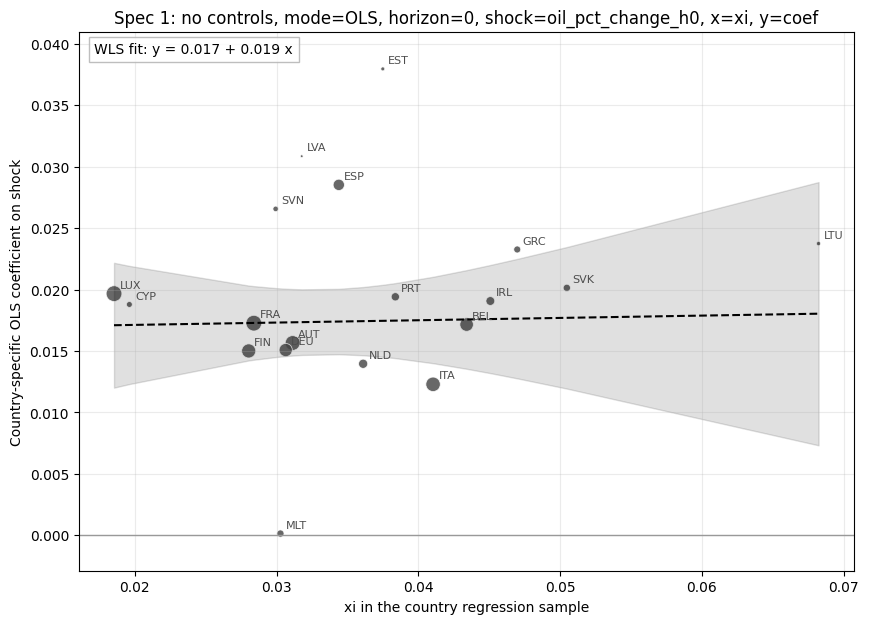

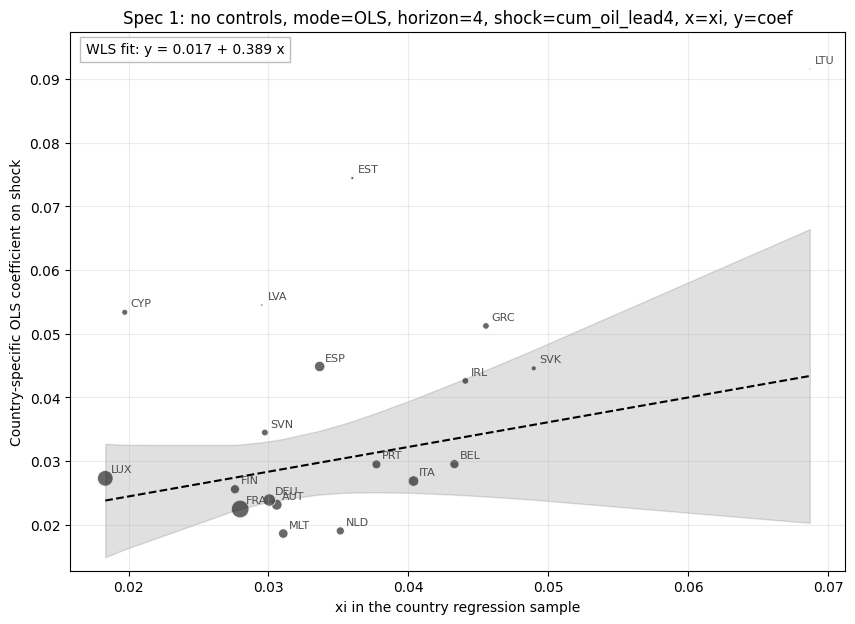

In [5]:
plot_coef_vs_weighted_xi(results_spec1, title_prefix="Spec 1: no controls", x_axis_metric=x_axis_metric, y_axis_mode=y_axis_mode)


## Spec 2: Lagged Macro Controls Only


In [6]:
results_spec2 = run_spec_for_horizons(
    panel_df,
    horizons=plot_horizons,
    include_lagged_controls=True,
    estimation_mode=estimation_mode,
)
print(f"Rows estimated: {len(results_spec2)}")
results_spec2.head()


Rows estimated: 38


,country,horizon,nobs,estimation_mode,shock_col,instrument_col,coef_shock,se_shock,shock_ci_low,shock_ci_high,...,first_stage_p,xi_average,xi_shock_weighted,xi_weighted,xi_amp1_average,xi_amp1_shock_weighted,xi_amp1_weighted,xi_amp2_average,xi_amp2_shock_weighted,xi_amp2_weighted
0,AUT,0,93,ols,oil_pct_change_h0,None,0.017173,0.002962,0.011272,0.023073,...,NaN,0.031128,0.029587,0.031128,0.010195,0.009460,0.010195,0.018159,0.017920,0.018159
1,BEL,0,93,ols,oil_pct_change_h0,None,0.018059,0.003235,0.011617,0.024501,...,NaN,0.043399,0.043127,0.043399,0.010146,0.010260,0.010146,0.017850,0.017458,0.017850
2,CYP,0,57,ols,oil_pct_change_h0,None,0.028044,0.008807,0.010245,0.045842,...,NaN,0.019613,0.018090,0.019613,0.005480,0.003909,0.005480,0.013232,0.013068,0.013232
3,DEU,0,93,ols,oil_pct_change_h0,None,0.017801,0.003077,0.011672,0.023929,...,NaN,0.030639,0.030004,0.030639,0.009556,0.009333,0.009556,0.013564,0.013435,0.013564
4,ESP,0,93,ols,oil_pct_change_h0,None,0.028999,0.003804,0.021423,0.036575,...,NaN,0.034384,0.033815,0.034384,0.009674,0.009513,0.009674,0.016503,0.016542,0.016503


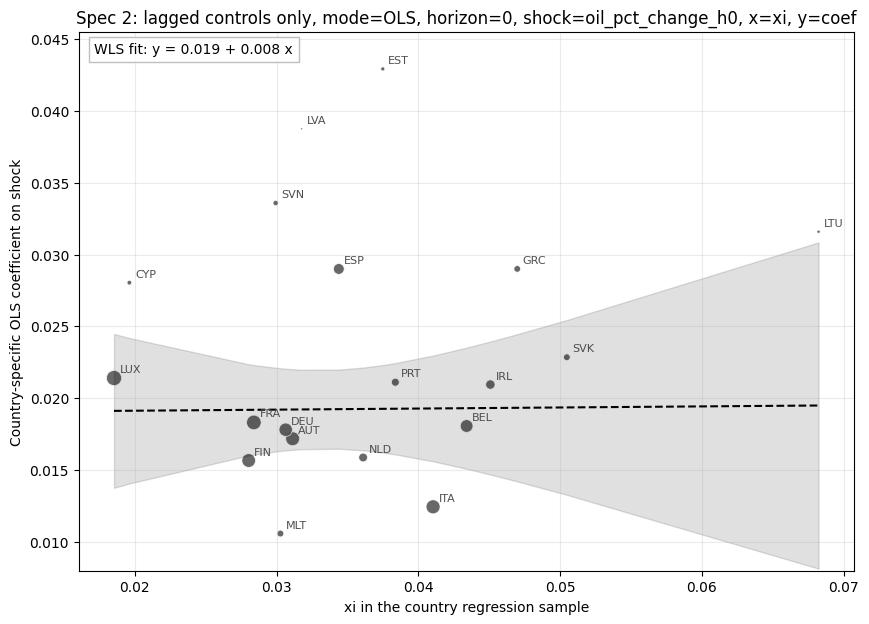

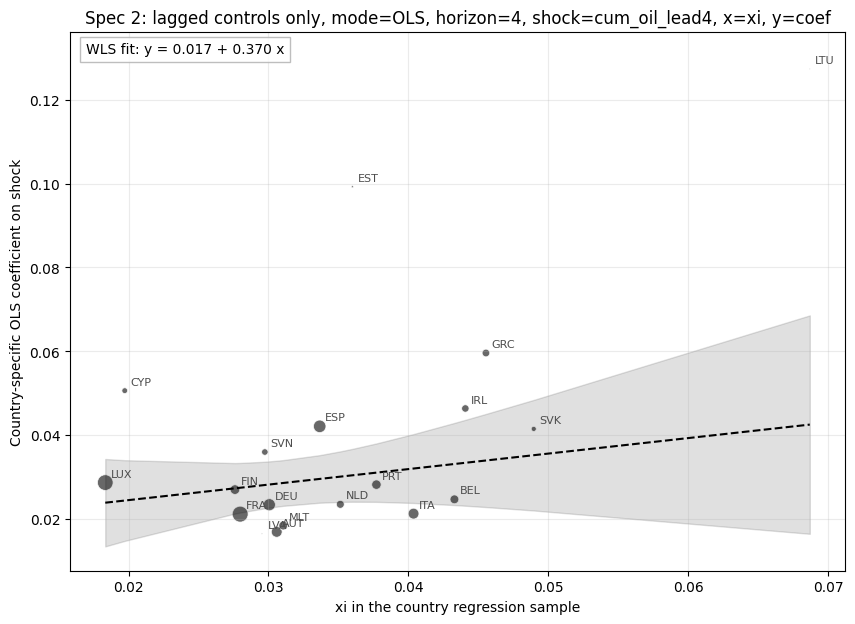

In [7]:
plot_coef_vs_weighted_xi(results_spec2, title_prefix="Spec 2: lagged controls only", x_axis_metric=x_axis_metric, y_axis_mode=y_axis_mode)


## Comparison Table


In [8]:
comparison_df = (
    results_spec1[["country", "horizon", "shock_col", "coef_shock", "se_shock", "weight_inv_var", "nobs", "xi_weighted", "xi_amp1_weighted", "xi_amp2_weighted"]]
    .rename(columns={
        "shock_col": "shock_col_spec1",
        "coef_shock": "coef_spec1",
        "se_shock": "se_spec1",
        "weight_inv_var": "weight_spec1",
        "nobs": "nobs_spec1",
        "xi_weighted": "xi_weighted_spec1",
        "xi_amp1_weighted": "xi_amp1_weighted_spec1",
        "xi_amp2_weighted": "xi_amp2_weighted_spec1",
    })
    .merge(
        results_spec2[["country", "horizon", "shock_col", "coef_shock", "se_shock", "weight_inv_var", "nobs", "xi_weighted", "xi_amp1_weighted", "xi_amp2_weighted"]].rename(columns={
            "shock_col": "shock_col_spec2",
            "coef_shock": "coef_spec2",
            "se_shock": "se_spec2",
            "weight_inv_var": "weight_spec2",
            "nobs": "nobs_spec2",
            "xi_weighted": "xi_weighted_spec2",
            "xi_amp1_weighted": "xi_amp1_weighted_spec2",
            "xi_amp2_weighted": "xi_amp2_weighted_spec2",
        }),
        on=["country", "horizon"],
        how="outer",
    )
    .sort_values(["horizon", "country"])
    .reset_index(drop=True)
)

comparison_df.head(20)


,country,horizon,shock_col_spec1,coef_spec1,se_spec1,weight_spec1,nobs_spec1,xi_weighted_spec1,xi_amp1_weighted_spec1,xi_amp2_weighted_spec1,shock_col_spec2,coef_spec2,se_spec2,weight_spec2,nobs_spec2,xi_weighted_spec2,xi_amp1_weighted_spec2,xi_amp2_weighted_spec2
0,AUT,0,oil_pct_change_h0,0.015652,0.002692,138041.128000,93,0.031128,0.010195,0.018159,oil_pct_change_h0,0.017173,0.002962,113943.369005,93,0.031128,0.010195,0.018159
1,BEL,0,oil_pct_change_h0,0.017154,0.002952,114739.452541,93,0.043399,0.010146,0.017850,oil_pct_change_h0,0.018059,0.003235,95583.631882,93,0.043399,0.010146,0.017850
2,CYP,0,oil_pct_change_h0,0.018787,0.006800,21624.225658,57,0.019613,0.005480,0.013232,oil_pct_change_h0,0.028044,0.008807,12894.152168,57,0.019613,0.005480,0.013232
3,DEU,0,oil_pct_change_h0,0.015080,0.003020,109678.472322,93,0.030639,0.009556,0.013564,oil_pct_change_h0,0.017801,0.003077,105618.713942,93,0.030639,0.009556,0.013564
4,ESP,0,oil_pct_change_h0,0.028519,0.003521,80683.042532,93,0.034384,0.009674,0.016503,oil_pct_change_h0,0.028999,0.003804,69112.254321,93,0.034384,0.009674,0.016503
5,EST,0,oil_pct_change_h0,0.037954,0.010120,9763.978119,45,0.037488,0.015033,0.020286,oil_pct_change_h0,0.042936,0.010248,9522.625719,45,0.037488,0.015033,0.020286
6,FIN,0,oil_pct_change_h0,0.015006,0.002827,125095.983025,81,0.028029,0.009837,0.015551,oil_pct_change_h0,0.015654,0.002997,111362.668440,81,0.028029,0.009837,0.015551
7,FRA,0,oil_pct_change_h0,0.017266,0.002543,154686.172138,93,0.028392,0.010740,0.015259,oil_pct_change_h0,0.018308,0.002820,125782.595248,93,0.028392,0.010740,0.015259
8,GRC,0,oil_pct_change_h0,0.023262,0.005689,30896.944439,85,0.046969,0.017903,0.018318,oil_pct_change_h0,0.029002,0.006166,26301.770283,85,0.046969,0.017903,0.018318
9,IRL,0,oil_pct_change_h0,0.019069,0.004539,48534.914427,81,0.045072,0.011644,0.011727,oil_pct_change_h0,0.020948,0.004415,51310.693622,81,0.045072,0.011644,0.011727


In [9]:
pd.DataFrame(
    {
        "note": [
            "Equality-test summaries were removed from this notebook."
        ]
    }
)


,note
0,Equality-test summaries were removed from this...


In [10]:
pd.DataFrame(
    {
        "note": [
            "Equality-test country lists were removed from this notebook."
        ]
    }
)


,note
0,Equality-test country lists were removed from ...


In [11]:
pd.DataFrame(
    {
        "note": [
            "Equality-test extracts were removed from this notebook."
        ]
    }
)


,note
0,Equality-test extracts were removed from this ...


In [12]:
spec2_h3_all_countries = sorted(
    results_spec2.loc[
        results_spec2["horizon"] == 3,
        "country",
    ].dropna().tolist()
)

spec2_h3_all_countries


[]

In [13]:
results_spec1_irf = run_spec_for_horizons(
    panel_df,
    horizons=irf_horizons,
    include_lagged_controls=False,
    estimation_mode=estimation_mode,
)
results_spec2_irf = run_spec_for_horizons(
    panel_df,
    horizons=irf_horizons,
    include_lagged_controls=True,
    estimation_mode=estimation_mode,
)

cross_section_summary_irf_spec1 = build_cross_section_summary_irf(
    results_spec1_irf,
    x_axis_metric=x_axis_metric,
    y_axis_mode=y_axis_mode,
    summary_mode=cross_section_summary_mode,
)
cross_section_summary_irf_spec2 = build_cross_section_summary_irf(
    results_spec2_irf,
    x_axis_metric=x_axis_metric,
    y_axis_mode=y_axis_mode,
    summary_mode=cross_section_summary_mode,
)

cross_section_summary_irf_comparison = pd.concat(
    [
        cross_section_summary_irf_spec1.assign(spec="Spec 1: no controls"),
        cross_section_summary_irf_spec2.assign(spec="Spec 2: lagged controls only"),
    ],
    ignore_index=True,
)

cross_section_summary_irf_comparison


,horizon,term,summary_mode,coef,std_err,t,p_value,ci_low_95,ci_high_95,nobs,n_countries,spec
0,0,xi_average,wls,0.018880,0.140400,0.134470,0.894610,-0.277338,0.315097,19.0,19,Spec 1: no controls
1,1,xi_average,wls,0.073543,0.185390,0.396695,0.696528,-0.317595,0.464681,19.0,19,Spec 1: no controls
2,2,xi_average,wls,0.177605,0.212356,0.836353,0.414559,-0.270428,0.625638,19.0,19,Spec 1: no controls
3,3,xi_average,wls,0.275664,0.253423,1.087765,0.291881,-0.259011,0.810339,19.0,19,Spec 1: no controls
4,4,xi_average,wls,0.388518,0.283474,1.370562,0.188339,-0.209559,0.986595,19.0,19,Spec 1: no controls
5,5,xi_average,wls,0.430761,0.336492,1.280149,0.217686,-0.279176,1.140697,19.0,19,Spec 1: no controls
6,6,xi_average,wls,0.472516,0.381701,1.237923,0.232569,-0.332802,1.277835,19.0,19,Spec 1: no controls
7,7,xi_average,wls,0.416070,0.396726,1.048759,0.308971,-0.420949,1.253088,19.0,19,Spec 1: no controls
8,8,xi_average,wls,0.409959,0.418846,0.978782,0.341412,-0.473729,1.293647,19.0,19,Spec 1: no controls
9,9,xi_average,wls,0.373120,0.436138,0.855510,0.404166,-0.547050,1.293290,19.0,19,Spec 1: no controls


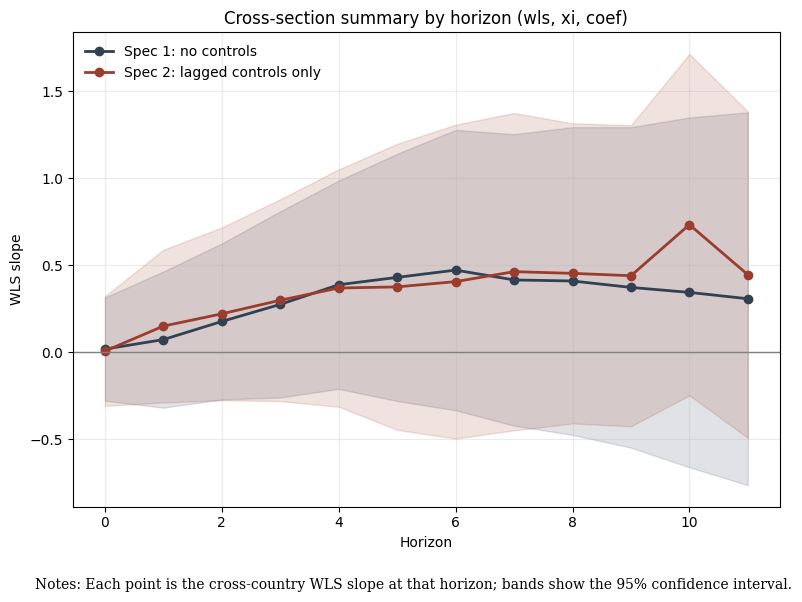

In [14]:
plot_cross_section_summary_irf_comparison(
    [
        ("Spec 1: no controls", cross_section_summary_irf_spec1),
        ("Spec 2: lagged controls only", cross_section_summary_irf_spec2),
    ],
    title=f"Cross-section summary by horizon ({cross_section_summary_mode}, {x_axis_metric}, {y_axis_mode})",
    summary_mode=cross_section_summary_mode,
)
